### Experiment 1 - Corpus statistics

In [1]:
import gzip
import json
import os

filepath = os.path.join("..", "data", "c4-train.00000-of-01024-30K.json.gz")
documents = []

with gzip.open(filepath, "rt", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        if 'text' in data:
            documents.append(data)
            
print("Number of documents: ",len(documents))

Number of documents:  30000


In [7]:
import re
from collections import Counter

num_sentences = 0

unigram_count = Counter()
bigram_count = Counter()
trigram_count = Counter()

for doc in documents:
    text = doc["text"]

    # Tách câu
    sentences = re.split(r'(?<=[.!?]) +', text)
    num_sentences += len(sentences)

    for sentence in sentences:
        # Tokenization
        tokens = re.findall(r'\b\w+\b', sentence.lower())

        if len(tokens) == 0:
            continue

        # Unigram
        for token in tokens:
            unigram_count[token] += 1

        # Bigram 
        for i in range (len(tokens) - 1):
            bigram = (tokens[i], tokens[i+1])
            bigram_count[bigram] += 1
            # bigram_count.update(bigram) if len(tokens) >= 2

        # Trigram
        for i in range (len(tokens) - 2):
            trigram = (tokens[i], tokens[i+1], tokens[i+2])
            trigram_count[trigram] += 1

num_tokens = sum(unigram_count.values())
vocab_size = len(unigram_count)

# N-gram chỉ xuất hiện 1 lần
unigrams_once = 0
for count in unigram_count.values():
    if count == 1:
        unigrams_once += 1

bigrams_once = 0
for count in bigram_count.values():
    if count == 1:
        bigrams_once += 1

trigrams_once = 0
for count in trigram_count.values():
    if count == 1:
        trigrams_once += 1

print("Số documents:", len(documents))
print("Số sentences:", num_sentences)
print("Số tokens:", num_tokens)
print("Vocabulary size:", vocab_size)

print("Unigram - unique:", len(unigram_count), "- xuất hiện 1 lần:", unigrams_once)

print("Bigram - unique:", len(bigram_count), "- xuất hiện 1 lần:", bigrams_once)

print("Trigram - unique:", len(trigram_count), "- xuất hiện 1 lần:", trigrams_once)

Số documents: 30000
Số sentences: 411688
Số tokens: 11090891
Vocabulary size: 193837
Unigram - unique: 193837 - xuất hiện 1 lần: 94219
Bigram  - unique: 2888909 - xuất hiện 1 lần: 2078920
Trigram - unique: 6859846 - xuất hiện 1 lần: 5949111


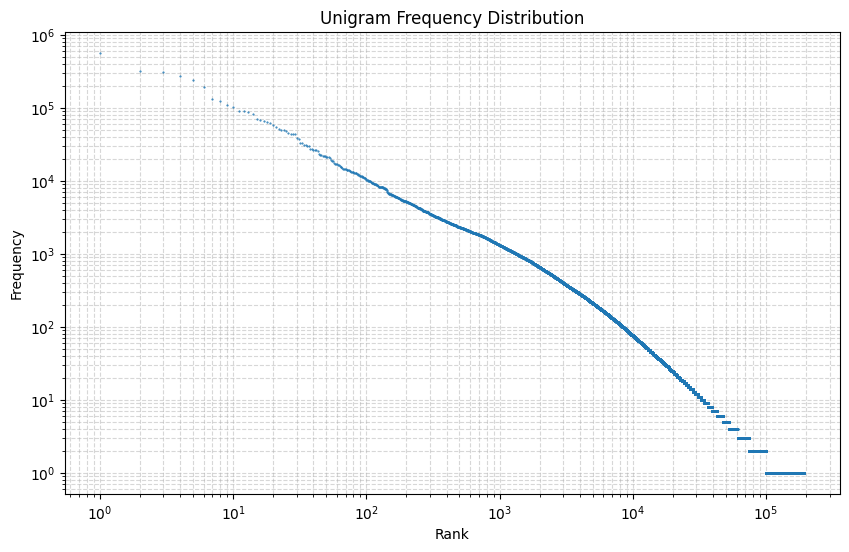

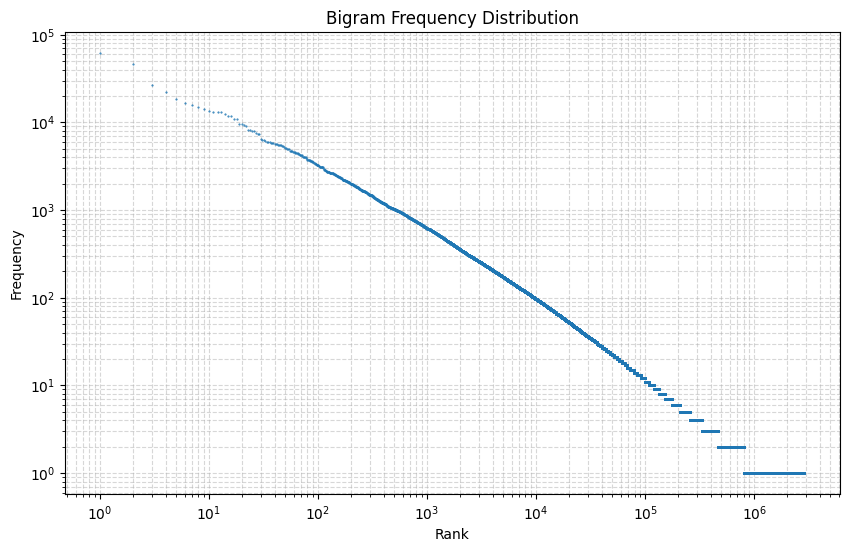

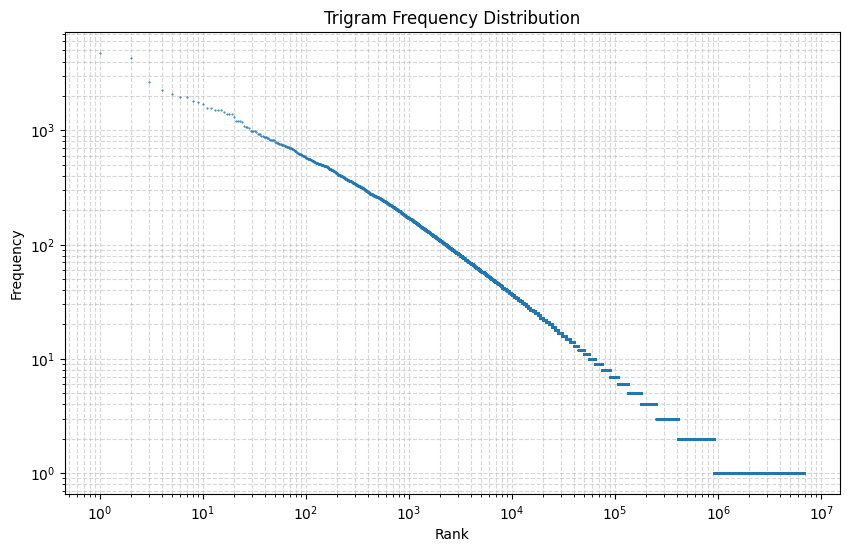

In [10]:
import matplotlib.pyplot as plt

def plot_frequency_distribution(counts, title):
    # Lấy frequency của tất cả n-gram => sắp xếp giảm dần
    frequencies = sorted(counts.values(), reverse=True)

    ranks = range(1, len(frequencies) + 1)

    # log-log
    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, frequencies, marker='.', linestyle='none', markersize=1)

    plt.title(title)
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)

    plt.show()


plot_frequency_distribution(unigram_count, "Unigram Frequency Distribution")

plot_frequency_distribution(bigram_count, "Bigram Frequency Distribution")

plot_frequency_distribution(trigram_count, "Trigram Frequency Distribution")